# Scikit Feature Tracking Algorithm -- Precipitation

### Overview

In this notebook, we utilize [scikit-image contour finding](https://scikit-image.org/docs/stable/auto_examples/edges/plot_contours.html) to detect regions in gridded climate data with low precipitation values based on a defined threshold. We label these areas as individual features and follow them through various time steps. We visualize these regions across time on a map using frame-to-frame overlap, allowing us to analyze how the precipitation systems move and evolve over time. 

### Import Packages

In [1]:
# Import necessary libraries for identifying contours and plotting
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from skimage.measure import label, regionprops
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import cartopy.crs as ccrs

Load in the data using `xarray`, and extract the variable of interest.

We want to look at the total precipitation of the extratropical cyclones, which is stored under the `ETC_tp` variable.

In [2]:
# Load in precipitation dataset
ds = xr.open_dataset('data/precip_ex.nc')

# Extratropical cyclone total precipitation
data = ds["ETC_tp"] 

### Exploratory Data Analysis

Let's take a look at this precipitation data for a single time stamp.

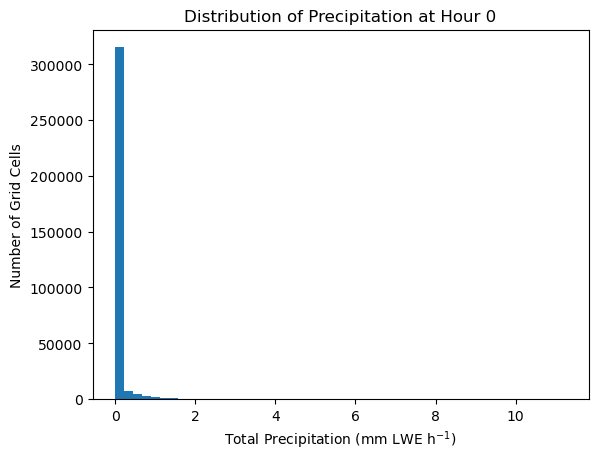

In [3]:
# Subsection the precipitation values at time = 0
hr_0_data = data.sel(time=data.time[0])

# Look at the range of total precipitation
plt.hist(hr_0_data.values.ravel(), bins=50)
plt.xlabel("Total Precipitation (mm LWE h$^{-1}$)")
plt.ylabel("Number of Grid Cells")
plt.title("Distribution of Precipitation at Hour 0")
plt.show()

The majority of precipitation values are between 0 and 2 mm. Let's use that as a filter so we can visualize the data in a way that corresponds to the bulk of the data, rather than a few askew values.

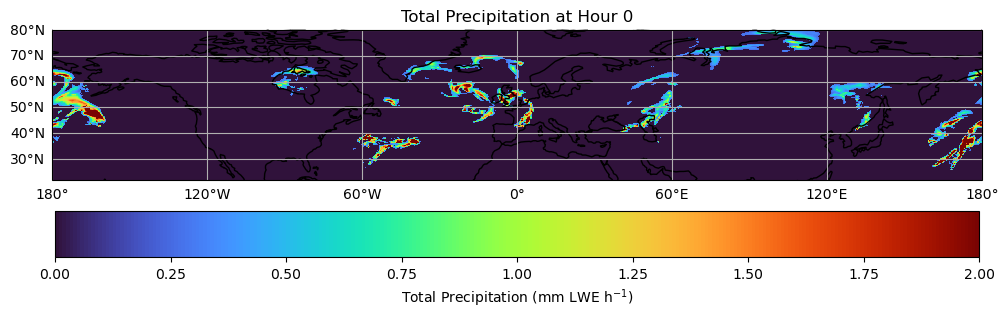

In [4]:
# Plot data at hour 0
fig, ax = plt.subplots(
    figsize=(12, 4),
    subplot_kw={"projection": ccrs.PlateCarree()}
)
hr_0_data.plot(
    ax=ax,
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=2,
    cmap="turbo",
    add_colorbar=False
)

# Add customizations (gridlines, colorbar)
ax.coastlines()
gl = ax.gridlines(draw_labels=True)
gl.top_labels = False
gl.right_labels = False
cbar = plt.colorbar(
    ax.collections[0],
    ax=ax,
    orientation="horizontal",
    pad=0.1
)

# Update labels and titles
cbar.set_label(r"Total Precipitation (mm LWE h$^{-1}$)")
plt.title("Total Precipitation at Hour 0")
plt.show()

### Track Features Over Time

We initialize the contour-detection parameters, and extract the latitude and longitude coordinates from the dataset. We then convert the coordinates into 2D grids so the found contours can be plotted in geographic space.

In [5]:
# Define parameters for contour finding
threshold = 100000
min_area = 20
min_overlap = 0.2 

# Extract latitutde and longitude coordinates
lat = data[data.dims[1]].values # assumes dims like (time, lat, lon)
lon = data[data.dims[2]].values

# Make 2D grids for contour
lon2d, lat2d = np.meshgrid(lon, lat)

The feature we want to detect is connected regions with total precipitation levels below our defined threshold.

We create a function to detect these features at each time step and assign each feature a track ID (`track_id`) so we can follow it from one time step to the next.

Our function follows this outline:
1. Detect features in the current field using a threshold and minimum area.
2. For each detected feature, compare it with features from the previous time step.
   - If the new feature overlaps enough (exceeds `min_area`) with an old feature, it keeps the same `track_id`. Otherwise, it is treated as a new feature and receives a new `track_id`.
3. Store the feature’s `track_id`, centroid location, and mask for plotting or later analysis.

In [6]:
def detect_features(
    field,
    threshold=threshold,
    min_area=min_area
):
    """
    Detect regions with a low total precipitation value (total precipitation <= threshold).
    """
    mask = field <= threshold
    labels = label(mask, connectivity=2)

    for lab in np.unique(labels)[1:]:
        if np.sum(labels == lab) < min_area:
            labels[labels == lab] = 0

    labels = label(labels > 0, connectivity=2)
    return labels

Note that our function identifies these features for a **single time step**. So to track these regions **over time**, we must iterate through all time steps present in our data, and call `detect_features` on each interval.

Run the tracking function for each time step, and save the results in a variable `tracked`.

In [7]:
# Initialize features tracked through time
tracked = []
prev = {}
next_track_id = 1

# Loop through all timesteps
for t in range(data.sizes["time"]):
    field = data.isel(time=t).values # 2D data field for the current time step
    labels = detect_features(field, threshold=threshold, min_area=min_area) # feature-detection

    current = {}
    frame_info = []

    for r in regionprops(labels):
        mask = labels == r.label
        best_id = None
        best_overlap = 0.0

        for track_id, old_mask in prev.items():
            overlap = np.logical_and(mask, old_mask).sum() / mask.sum()
            if overlap > best_overlap:
                best_overlap = overlap
                best_id = track_id

        if best_overlap < min_overlap:
            best_id = next_track_id
            next_track_id += 1

        current[best_id] = mask
        frame_info.append({
            "track_id": best_id,
            "centroid_rc": r.centroid,
            "mask": mask
        })

    tracked.append(frame_info)
    prev = current

In the visualization, we will have a colorbar that represent precipitation levels. We want the bar to accurately depict the bulk of the data, so we limit the lower end to the 1st percentile of the data, and the upper end to the 99th percentile.

In [8]:
# Find 1st percentile and 99th percentile of total precipitation values
vals = data.values
vmin = np.nanpercentile(vals, 1)
vmax = np.nanpercentile(vals, 99)

levels = np.linspace(vmin, vmax, 16) # evenly spaced intervals
norm = mcolors.Normalize(vmin=vmin, vmax=vmax) # normalize
cmap = 'turbo' # colormap

We can animate the storm tracked over time by plotting the low precipitation regions at each timestep.

In [9]:
def update(t):
    """
    Animation function, called once for each timestep in the dataset.
    """
    # Reset the map on each timestep
    ax.clear()
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.set_aspect('auto')

    field = data.isel(time=t).values # total precipitation data for current timestep

    # Colored contour lines
    cs = ax.contour(
        lon2d, lat2d, field,
        levels=levels,
        cmap=cmap,         
        linewidths=0.9,
        transform=ccrs.PlateCarree()
    )

    # tracked feature outlines + labels
    for feat in tracked[t]:
        mask = feat["mask"]

        ax.contour(
            lon2d, lat2d, mask.astype(int),
            levels=[0.5],
            colors="black",
            linewidths=1.6,
            transform=ccrs.PlateCarree()
        )

        y, x = feat["centroid_rc"]
        iy = int(round(y))
        ix = int(round(x))

        ax.plot(
            lon[ix], lat[iy],
            "ko", ms=3,
            transform=ccrs.PlateCarree()
        )

        ax.text(
            lon[ix], lat[iy],
            str(feat["track_id"]),
            fontsize=8,
            color="black",
            ha="left",
            va="bottom",
            transform=ccrs.PlateCarree(),
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.7, pad=1)
        )

    # Create outlines for continents/coastlines and gridlines
    ax.coastlines(color="0.55", linewidth=0.6)
    gl = ax.gridlines(
        draw_labels=True,
        linewidth=0.4,
        color="0.5",
        alpha=0.25,
        linestyle="--"
    )
    
    gl.top_labels = False
    gl.right_labels = False
    ax.set_title(f"Extratropical cyclone precipitation features at hour {t}")

In [10]:
# Create map
fig, ax = plt.subplots(figsize=(13, 5), subplot_kw={"projection": ccrs.PlateCarree()})
extent = [lon.min(), lon.max(), lat.min(), lat.max()] # geographic boundaries of the map
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Create colorbar
sm = ScalarMappable(norm=norm, cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(
    sm,
    ax=ax,
    pad=0.15,
    orientation = 'horizontal'
)
cbar.set_label("Total Precipitation (mm LWE h$^{-1}$)")

# Create animation
anim = FuncAnimation(
    fig,
    update,
    frames=data.sizes["time"],
    interval=300,
    blit=False,
)

plt.close(fig)
HTML(anim.to_jshtml())

This animation showcases the total precipitation values of low precipitation systems from hours 0 to 12. These feature systems appear between the latitudes 30°N and 70°N (hence the boundaries of the map) which is typical for an extratropical cyclone.

Through tracking, we see that most of the systems head towards the East as the hour increases. We also are able to track whether these precipitation areas break apart, which is typical behavior during an extratropical cyclone. For example, see the leftmost precipitation system on the map. It heads toward the East direction and splits at hour 7.